In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pykrige.ok import OrdinaryKriging

d = pd.read_csv('../data/data PM10 mean 2025.csv', sep=";")

# Filtrer la France métropolitaine
d_metro = d[
    (d["validité"] == 1) &
    (d["Latitude"].between(41.0, 51.5)) &
    (d["Longitude"].between(-5.5, 10.0))
].dropna(subset=["Latitude", "Longitude", "valeur"])

print(d_metro["nom site"].nunique())

297


# Isotropie

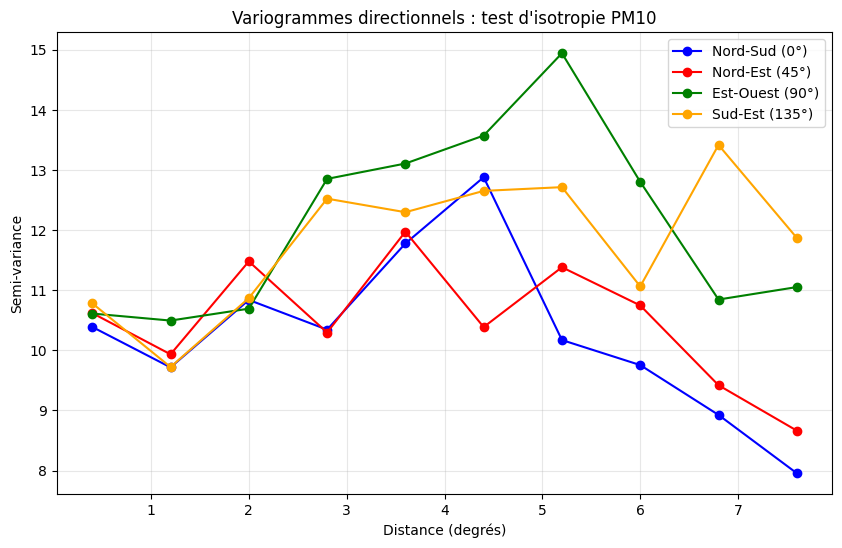

In [3]:
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

directions = [0, 45, 90, 135]
labels = ["Nord-Sud (0°)", "Nord-Est (45°)", "Est-Ouest (90°)", "Sud-Est (135°)"]
colors = ["blue", "red", "green", "orange"]

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

def variogramme_directionnel(lons, lats, vals, azimuth, tolerance=22.5, n_lags=10):
    coords = np.column_stack([lons, lats])
    bins = np.linspace(0, 8, n_lags + 1)
    gamma = []
    
    for k in range(n_lags):
        paires = []
        for i in range(len(coords)):
            for j in range(i+1, len(coords)):
                dx = coords[j,0] - coords[i,0]
                dy = coords[j,1] - coords[i,1]
                dist = np.sqrt(dx**2 + dy**2)
                angle = np.degrees(np.arctan2(dy, dx)) % 180
                
                if bins[k] <= dist < bins[k+1]:
                    if abs(angle - azimuth) <= tolerance or abs(angle - azimuth - 180) <= tolerance:
                        paires.append((vals[i] - vals[j])**2)
        
        gamma.append(np.mean(paires) / 2 if paires else np.nan)
    
    return (bins[:-1] + bins[1:]) / 2, gamma

plt.figure(figsize=(10, 6))
for azimuth, label, color in zip(directions, labels, colors):
    bins_mid, gamma = variogramme_directionnel(lons, lats, vals, azimuth)
    plt.plot(bins_mid, gamma, marker="o", label=label, color=color)

plt.xlabel("Distance (degrés)")
plt.ylabel("Semi-variance")
plt.title("Variogrammes directionnels : test d'isotropie PM10")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## NB LAGS

In [27]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

coords = d_metro[["Longitude", "Latitude"]].values

# Distance maximale
dist_max = cdist(coords, coords).max()

# Distance moyenne au plus proche voisin
nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
distances, _ = nbrs.kneighbors(coords)
dist_voisins = distances[:, 1].mean()

# Calcul nlags optimal
lag_size = dist_voisins  # lag_size = distance moyenne au plus proche voisin
nlags_optimal = int((dist_max / 2) / lag_size)

print(f"Distance maximale       : {dist_max:.2f}°")
print(f"Lag size (dist voisins) : {lag_size:.2f}°")
print(f"nlags optimal           : {nlags_optimal}")
print(f"Couverture totale       : {lag_size * nlags_optimal:.2f}° (doit ≈ {dist_max/2:.2f}°)")

Distance maximale       : 15.14°
Lag size (dist voisins) : 0.17°
nlags optimal           : 43
Couverture totale       : 7.42° (doit ≈ 7.57°)


In [29]:
n = 297
n_paires = n * (n - 1) // 2
print(f"Nombre de paires total : {n_paires}")
print(f"Paires moyennes par lag (nlags=43) : {n_paires / 43:.0f}")
print(f"Paires moyennes par lag (nlags=15) : {n_paires / 15:.0f}")
print(f"Paires moyennes par lag (nlags=20) : {n_paires / 20:.0f}")

Nombre de paires total : 43956
Paires moyennes par lag (nlags=43) : 1022
Paires moyennes par lag (nlags=15) : 2930
Paires moyennes par lag (nlags=20) : 2198


# Comparaison (Ordinary)

### Isotropes

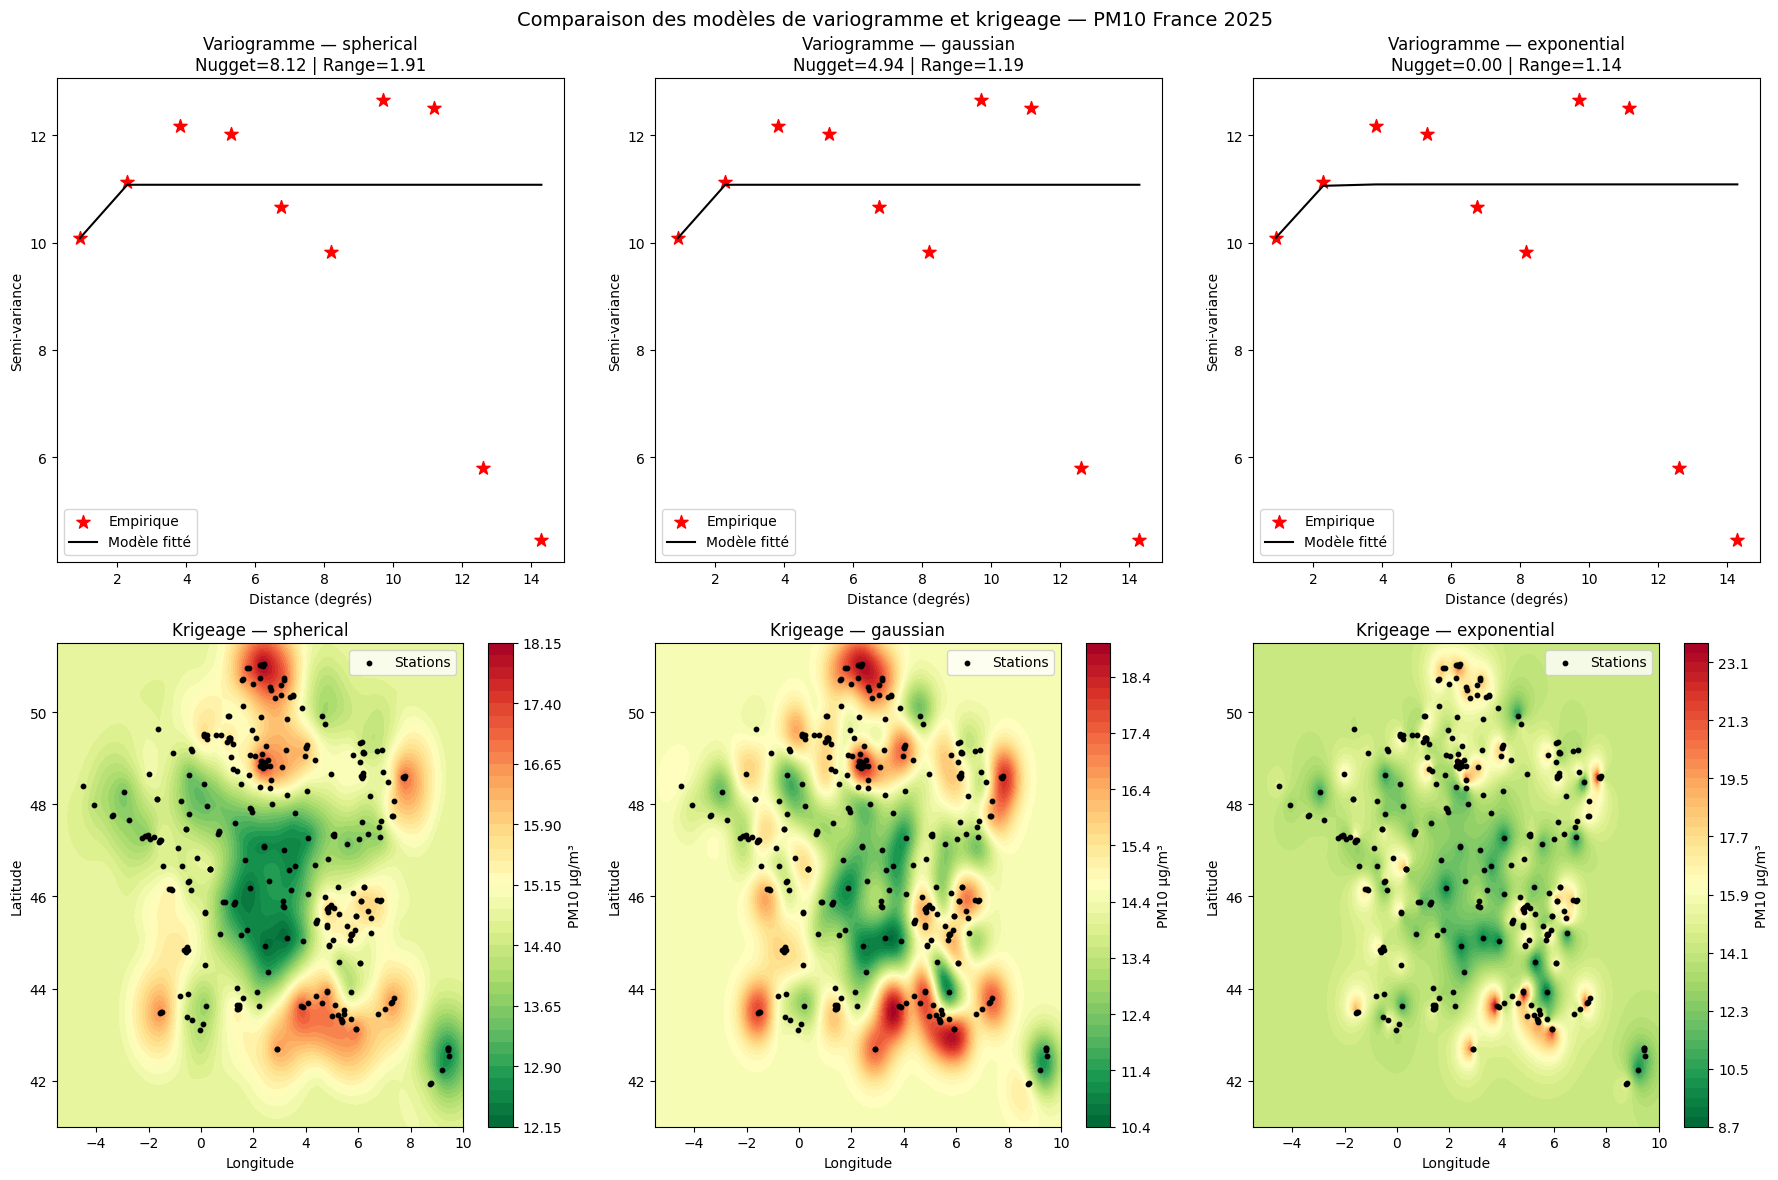

In [5]:
modeles = ["spherical", "gaussian", "exponential"]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

for col, modele in enumerate(modeles):
    OK = OrdinaryKriging(
        lons, lats, vals,
        variogram_model=modele,
        nlags=10,
        verbose=False,
        enable_plotting=False
    )
    
    # --- Ligne 1 : variogramme ---
    ax_vario = axes[0, col]
    lags = OK.lags
    semivariance = OK.semivariance
    variogram_model_points = OK.variogram_function(OK.variogram_model_parameters, lags)
    
    ax_vario.scatter(lags, semivariance, c="red", marker="*", s=100, label="Empirique")
    ax_vario.plot(lags, variogram_model_points, "k-", label="Modèle fitté")
    ax_vario.set_title(f"Variogramme — {modele}\nNugget={OK.variogram_model_parameters[2]:.2f} | Range={OK.variogram_model_parameters[1]:.2f}")
    ax_vario.set_xlabel("Distance (degrés)")
    ax_vario.set_ylabel("Semi-variance")
    ax_vario.legend()

    # --- Ligne 2 : carte krigeage ---
    z, variance = OK.execute("grid", grid_lon, grid_lat)
    
    ax_map = axes[1, col]
    cf = ax_map.contourf(grid_lon, grid_lat, z, levels=50, cmap="RdYlGn_r")
    ax_map.scatter(lons, lats, c="black", s=10, label="Stations")
    plt.colorbar(cf, ax=ax_map, label="PM10 µg/m³")
    ax_map.set_title(f"Krigeage — {modele}")
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.legend()

plt.suptitle("Comparaison des modèles de variogramme et krigeage — PM10 France 2025", fontsize=14)
plt.tight_layout()
plt.show()

### Anisotrope

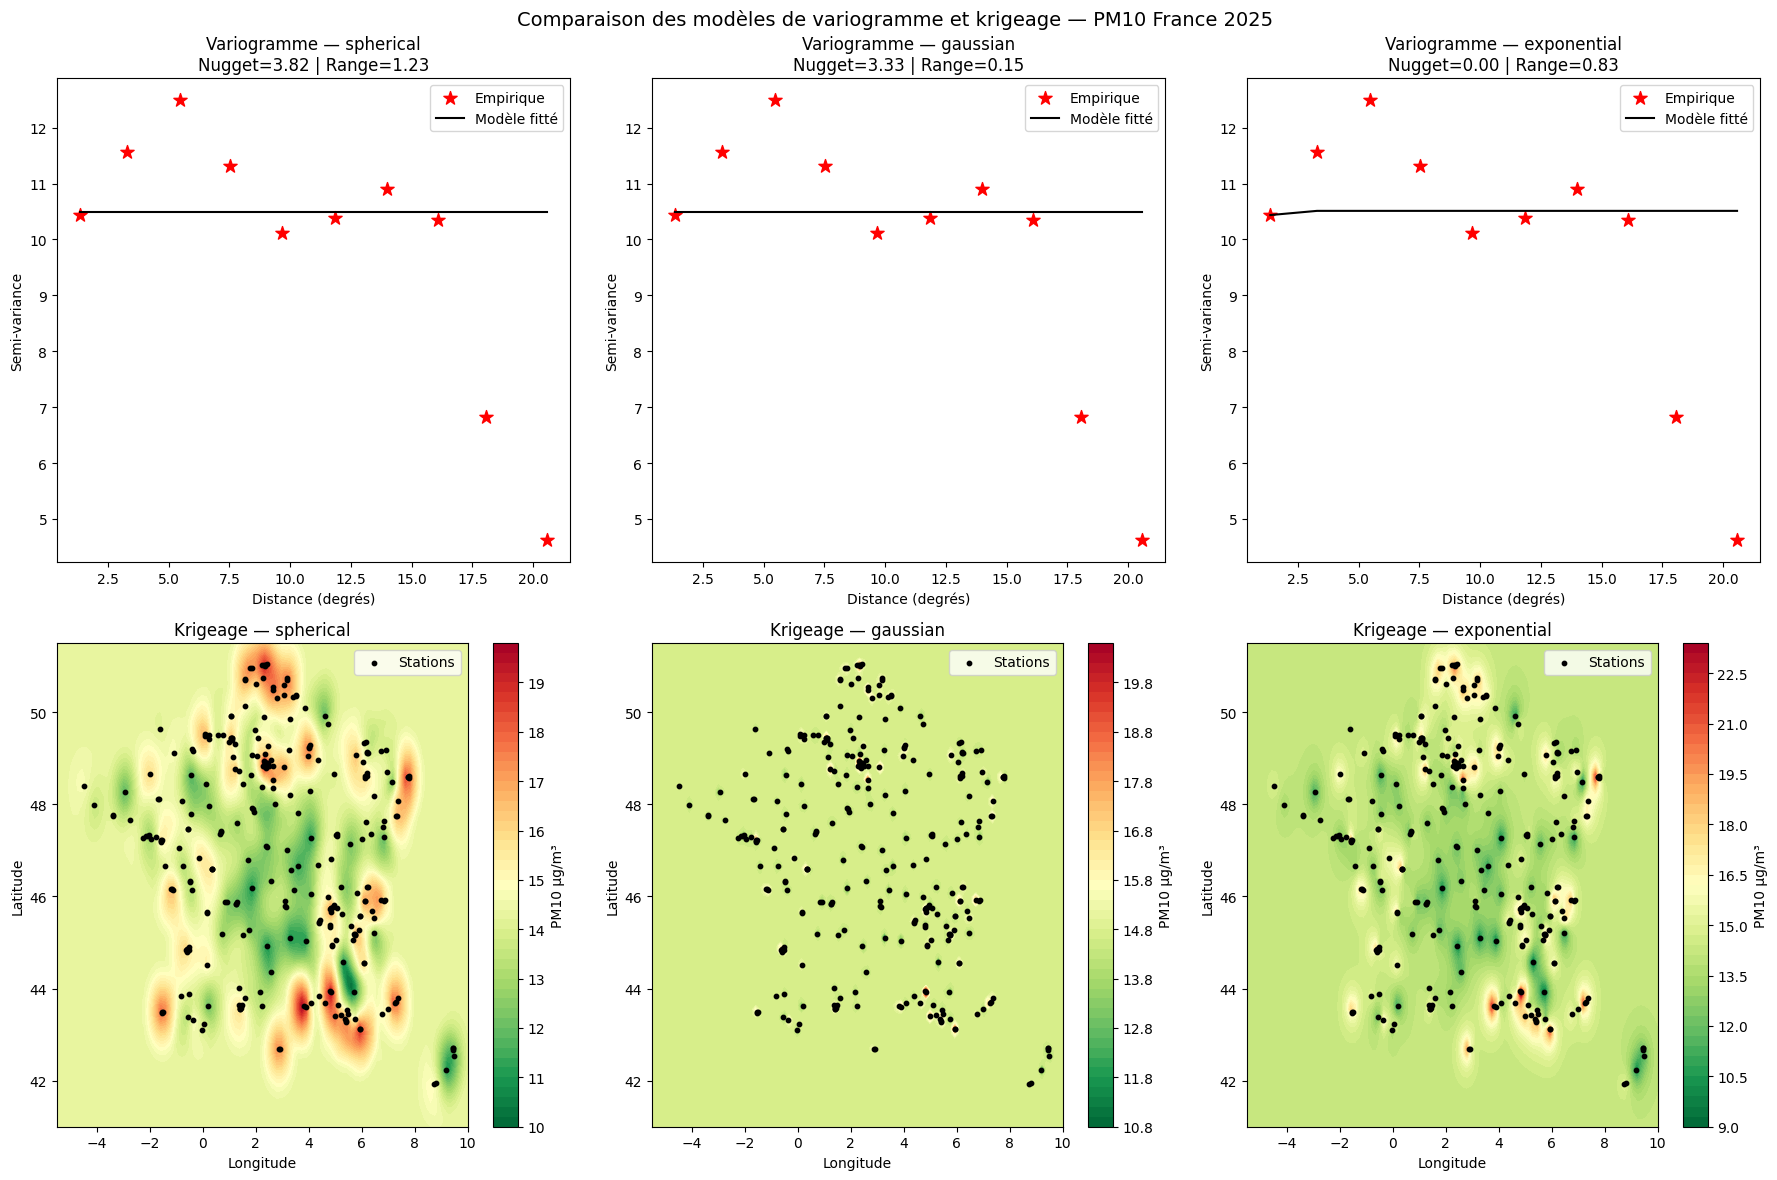

In [11]:
modeles = ["spherical", "gaussian", "exponential"]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

for col, modele in enumerate(modeles):
    OK = OrdinaryKriging(
        lons, lats, vals,
        variogram_model=modele,
        nlags=10,
        anisotropy_scaling=1.5,  # ratio des portées
        anisotropy_angle=90      # direction principale
    )
    
    # --- Ligne 1 : variogramme ---
    ax_vario = axes[0, col]
    lags = OK.lags
    semivariance = OK.semivariance
    variogram_model_points = OK.variogram_function(OK.variogram_model_parameters, lags)
    
    ax_vario.scatter(lags, semivariance, c="red", marker="*", s=100, label="Empirique")
    ax_vario.plot(lags, variogram_model_points, "k-", label="Modèle fitté")
    ax_vario.set_title(f"Variogramme — {modele}\nNugget={OK.variogram_model_parameters[2]:.2f} | Range={OK.variogram_model_parameters[1]:.2f}")
    ax_vario.set_xlabel("Distance (degrés)")
    ax_vario.set_ylabel("Semi-variance")
    ax_vario.legend()

    # --- Ligne 2 : carte krigeage ---
    z, variance = OK.execute("grid", grid_lon, grid_lat)
    
    ax_map = axes[1, col]
    cf = ax_map.contourf(grid_lon, grid_lat, z, levels=50, cmap="RdYlGn_r")
    ax_map.scatter(lons, lats, c="black", s=10, label="Stations")
    plt.colorbar(cf, ax=ax_map, label="PM10 µg/m³")
    ax_map.set_title(f"Krigeage — {modele}")
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.legend()

plt.suptitle("Comparaison des modèles de variogramme et krigeage — PM10 France 2025", fontsize=14)
plt.tight_layout()
plt.show()

## Validation croisée

### Isotrope

In [ ]:
resultats = {}

for nlags in range(5, 21):
    resultats[nlags] = {}
    for modele in ["spherical", "gaussian", "exponential"]:
        predicted = []
        for i in range(len(lons)):
            lons_cv = np.delete(lons, i)
            lats_cv = np.delete(lats, i)
            vals_cv = np.delete(vals, i)
            OK_cv = OrdinaryKriging(
                lons_cv, lats_cv, vals_cv,
                variogram_model=modele,
                nlags=nlags,
                verbose=False,
                enable_plotting=False
            )
            z, _ = OK_cv.execute("points", [lons[i]], [lats[i]])
            predicted.append(z[0])

        rmse = np.sqrt(np.mean((vals - np.array(predicted))**2))
        mae = np.mean(np.abs(vals - np.array(predicted)))
        resultats[nlags][modele] = {"RMSE": rmse, "MAE": mae}

# Affichage
print(f"{'nlags':<8} {'Modèle':<14} {'RMSE':>10} {'MAE':>10}")
print("-" * 45)
for nlags, modeles in resultats.items():
    for modele, metrics in modeles.items():
        print(f"{nlags:<8} {modele:<14} {metrics['RMSE']:>10.3f} {metrics['MAE']:>10.3f}")
    print()

nlags    Modèle               RMSE        MAE
---------------------------------------------
5        spherical           3.059      2.262
5        gaussian            3.144      2.320
5        exponential         3.498      2.629

6        spherical           3.067      2.264
6        gaussian            3.135      2.313
6        exponential         3.478      2.618

7        spherical           3.118      2.321
7        gaussian            3.981      2.581
7        exponential         3.471      2.617

8        spherical           3.118      2.316
8        gaussian            3.108      2.291
8        exponential         3.431      2.592

9        spherical           3.091      2.304
9        gaussian            3.232      2.407
9        exponential         3.451      2.605

10       spherical           3.084      2.263
10       gaussian            3.201      2.356
10       exponential         3.422      2.591

11       spherical           3.158      2.369
11       gaussian           

In [ ]:
# Construire le dataframe
rows = []
for nlags, modeles in resultats.items():
    for modele, metrics in modeles.items():
        rows.append({"nlags": nlags, "modele": modele, "RMSE": metrics["RMSE"], "MAE": metrics["MAE"]})

df_resultats = pd.DataFrame(rows)

# Classement par RMSE
df_classement = df_resultats.sort_values("RMSE").reset_index(drop=True)
df_classement.index += 1
df_classement.columns = ["nlags", "Modèle", "RMSE", "MAE"]

print("TOP 10 — classement par RMSE")
print(df_classement.head(10).to_string())

print("\nMeilleur nlags par modèle :")
print(df_resultats.loc[df_resultats.groupby("modele")["RMSE"].idxmin()].to_string(index=False))

TOP 10 — classement par RMSE
    nlags       Modèle      RMSE       MAE
1       5    spherical  3.059044  2.262278
2       6    spherical  3.067429  2.264300
3      10    spherical  3.084015  2.263255
4       9    spherical  3.091176  2.304088
5      14  exponential  3.101697  2.291542
6       8     gaussian  3.107752  2.290505
7      15  exponential  3.111054  2.308335
8      14    spherical  3.111517  2.320994
9      13  exponential  3.116941  2.345105
10      8    spherical  3.117592  2.316095

Meilleur nlags par modèle :
 nlags      modele     RMSE      MAE
    14 exponential 3.101697 2.291542
     8    gaussian 3.107752 2.290505
     5   spherical 3.059044 2.262278


### Anisotrope

In [8]:
resultats = {}

for nlags in range(5, 21):
    resultats[nlags] = {}
    for modele in ["spherical", "gaussian", "exponential"]:
        predicted = []
        for i in range(len(lons)):
            lons_cv = np.delete(lons, i)
            lats_cv = np.delete(lats, i)
            vals_cv = np.delete(vals, i)
            OK_cv = OrdinaryKriging(
                lons_cv, lats_cv, vals_cv,
                variogram_model=modele,
                nlags=nlags,
                anisotropy_scaling=1.5,  # ratio des portées
                anisotropy_angle=90      # direction principale
            )
            z, _ = OK_cv.execute("points", [lons[i]], [lats[i]])
            predicted.append(z[0])

        rmse = np.sqrt(np.mean((vals - np.array(predicted))**2))
        mae = np.mean(np.abs(vals - np.array(predicted)))
        resultats[nlags][modele] = {"RMSE": rmse, "MAE": mae}

# Affichage
print(f"{'nlags':<8} {'Modèle':<14} {'RMSE':>10} {'MAE':>10}")
print("-" * 45)
for nlags, modeles in resultats.items():
    for modele, metrics in modeles.items():
        print(f"{nlags:<8} {modele:<14} {metrics['RMSE']:>10.3f} {metrics['MAE']:>10.3f}")
    print()

nlags    Modèle               RMSE        MAE
---------------------------------------------
5        spherical           3.074      2.260
5        gaussian            3.087      2.324
5        exponential         3.212      2.408

6        spherical           3.071      2.265
6        gaussian            3.176      2.416
6        exponential         3.160      2.383

7        spherical           3.154      2.388
7        gaussian            3.185      2.424
7        exponential         3.182      2.390

8        spherical           3.106      2.306
8        gaussian            3.136      2.422
8        exponential         3.235      2.435

9        spherical           3.127      2.316
9        gaussian            3.183      2.398
9        exponential         3.222      2.432

10       spherical           3.131      2.324
10       gaussian            3.303      2.408
10       exponential         3.440      2.595

11       spherical           3.120      2.324
11       gaussian           

In [9]:
rows = []
for nlags, modeles in resultats.items():
    for modele, metrics in modeles.items():
        rows.append({"nlags": nlags, "modele": modele, "RMSE": metrics["RMSE"], "MAE": metrics["MAE"]})

df_resultats = pd.DataFrame(rows)

# Classement par RMSE
df_classement = df_resultats.sort_values("RMSE").reset_index(drop=True)
df_classement.index += 1
df_classement.columns = ["nlags", "Modèle", "RMSE", "MAE"]

print("TOP 10 — classement par RMSE")
print(df_classement.head(10).to_string())

print("\nMeilleur nlags par modèle :")
print(df_resultats.loc[df_resultats.groupby("modele")["RMSE"].idxmin()].to_string(index=False))

TOP 10 — classement par RMSE
    nlags     Modèle      RMSE       MAE
1       6  spherical  3.071223  2.264948
2       5  spherical  3.073728  2.260497
3       5   gaussian  3.086811  2.324129
4       8  spherical  3.106190  2.305792
5      16  spherical  3.110183  2.339155
6      15  spherical  3.112092  2.345755
7      11  spherical  3.120326  2.323555
8      12  spherical  3.126327  2.329348
9      19  spherical  3.126505  2.345271
10      9  spherical  3.126865  2.315751

Meilleur nlags par modèle :
 nlags      modele     RMSE      MAE
     6 exponential 3.159744 2.382854
     5    gaussian 3.086811 2.324129
     6   spherical 3.071223 2.264948


# Universal Kriging

In [4]:
from pykrige.uk import UniversalKriging
import numpy as np

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

modeles = ["spherical", "gaussian", "exponential"]
resultats_uk = {}

for nlags in range(5, 21):
    print(f"Calculs Universal Kriging : nlags={nlags}")
    resultats_uk[nlags] = {}
    for modele in modeles:
        predicted = []
        for i in range(len(lons)):
            lons_cv = np.delete(lons, i)
            lats_cv = np.delete(lats, i)
            vals_cv = np.delete(vals, i)
            
            UK_cv = UniversalKriging(
                lons_cv, lats_cv, vals_cv,
                variogram_model=modele,
                drift_terms=["regional_linear"],
                nlags=nlags,
                anisotropy_scaling=1.5,
                anisotropy_angle=90,
                verbose=False,
                enable_plotting=False
            )
            z, _ = UK_cv.execute("points", [lons[i]], [lats[i]])
            predicted.append(z[0])

        rmse = np.sqrt(np.mean((vals - np.array(predicted))**2))
        mae = np.mean(np.abs(vals - np.array(predicted)))
        resultats_uk[nlags][modele] = {"RMSE": rmse, "MAE": mae}

# Affichage classement
rows = []
for nlags, modeles_res in resultats_uk.items():
    for modele, metrics in modeles_res.items():
        rows.append({"nlags": nlags, "modele": modele, "RMSE": metrics["RMSE"], "MAE": metrics["MAE"]})

df_uk = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
df_uk.index += 1
df_uk.columns = ["nlags", "Modèle", "RMSE", "MAE"]

print("TOP 10 Universal Kriging — classement par RMSE")
print(df_uk.head(10).to_string())

print("\nMeilleur nlags par modèle :")
df_raw = pd.DataFrame(rows)
print(df_raw.loc[df_raw.groupby("modele")["RMSE"].idxmin()].to_string(index=False))

Calculs Universal Kriging : nlags=5
Calculs Universal Kriging : nlags=6
Calculs Universal Kriging : nlags=7
Calculs Universal Kriging : nlags=8
Calculs Universal Kriging : nlags=9
Calculs Universal Kriging : nlags=10
Calculs Universal Kriging : nlags=11
Calculs Universal Kriging : nlags=12
Calculs Universal Kriging : nlags=13
Calculs Universal Kriging : nlags=14
Calculs Universal Kriging : nlags=15
Calculs Universal Kriging : nlags=16
Calculs Universal Kriging : nlags=17
Calculs Universal Kriging : nlags=18
Calculs Universal Kriging : nlags=19
Calculs Universal Kriging : nlags=20
TOP 10 Universal Kriging — classement par RMSE
    nlags     Modèle      RMSE       MAE
1       6  spherical  3.079375  2.272125
2       5  spherical  3.079791  2.265410
3       5   gaussian  3.084688  2.302342
4      16  spherical  3.108858  2.316353
5      15  spherical  3.109422  2.324413
6       8  spherical  3.113528  2.311506
7       8   gaussian  3.124524  2.411702
8      19  spherical  3.126868  2.3273

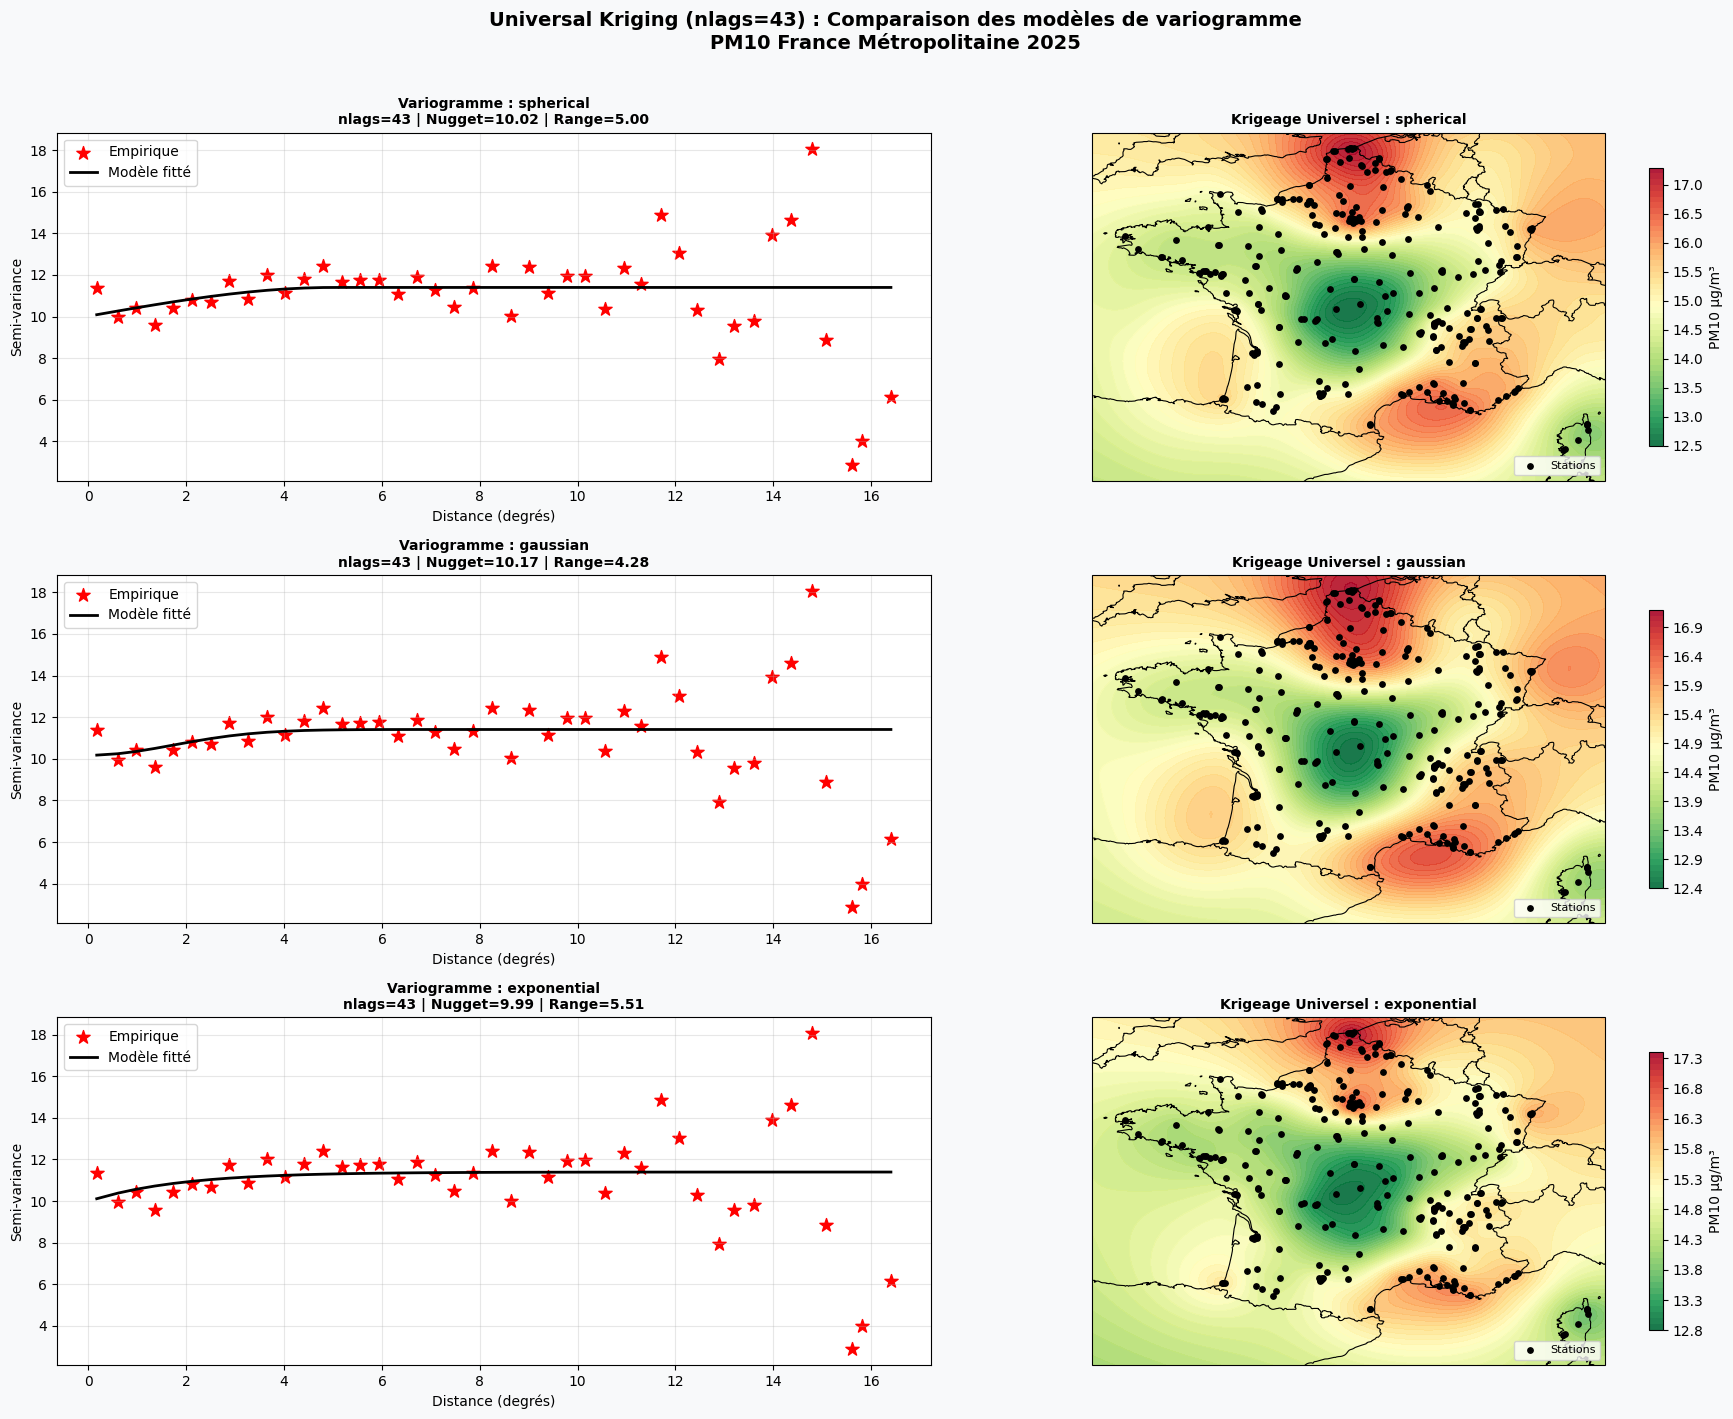

In [40]:
from pykrige.uk import UniversalKriging
import cartopy.crs as ccrs
import cartopy.feature as cfeature
nlags_choisi = 43  # change cette valeur

modeles = ["spherical", "gaussian", "exponential"]

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#f8f9fa')

for idx, modele in enumerate(modeles):
    UK_cv = UniversalKriging(
                lons_cv, lats_cv, vals_cv,
                variogram_model=modele,
                drift_terms=["regional_linear"],
                nlags=nlags_choisi,
                anisotropy_scaling=1.5,
                anisotropy_angle=0,
                verbose=False,
                enable_plotting=False
            )
    # UK_cv = UniversalKriging(
    #     lons_cv, lats_cv, vals_cv,
    #     variogram_model=modele,
    #     variogram_parameters=[10, 3, 2],  # sill, range, nugget
    #     drift_terms=["regional_linear"],
    #     nlags=nlags,
    #     anisotropy_scaling=1.5,
    #     anisotropy_angle=90,
    #     verbose=False,
    #     enable_plotting=False
    # )

    z, variance = UK_cv.execute("grid", grid_lon, grid_lat)

    # --- Variogramme ---
    ax_vario = fig.add_subplot(3, 2, idx * 2 + 1)
    lags_v = UK_cv.lags
    semi_v = UK_cv.semivariance
    model_v = UK_cv.variogram_function(UK_cv.variogram_model_parameters, lags_v)

    ax_vario.scatter(lags_v, semi_v, c="red", marker="*", s=100, label="Empirique")
    ax_vario.plot(lags_v, model_v, "k-", linewidth=2, label="Modèle fitté")
    ax_vario.set_title(f"Variogramme : {modele}\nnlags={nlags_choisi} | Nugget={UK_cv.variogram_model_parameters[2]:.2f} | Range={UK_cv.variogram_model_parameters[1]:.2f}",
                       fontsize=10, fontweight='bold')
    ax_vario.set_xlabel("Distance (degrés)")
    ax_vario.set_ylabel("Semi-variance")
    ax_vario.legend()
    ax_vario.set_facecolor('white')
    ax_vario.grid(alpha=0.3)

    # --- Carte krigeage ---
    ax_map = fig.add_subplot(3, 2, idx * 2 + 2, projection=ccrs.PlateCarree())
    ax_map.set_extent([-5.5, 10.0, 41.0, 51.5], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='black')
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax_map.add_feature(cfeature.LAND, facecolor='#f5f5f5')

    cf = ax_map.contourf(grid_lon, grid_lat, z, levels=50,
                          cmap="RdYlGn_r", transform=ccrs.PlateCarree(), alpha=0.9)
    ax_map.scatter(lons, lats, c="black", s=15, transform=ccrs.PlateCarree(),
                   zorder=5, label="Stations")
    plt.colorbar(cf, ax=ax_map, label="PM10 µg/m³", shrink=0.8)
    ax_map.set_title(f"Krigeage Universel : {modele}", fontsize=10, fontweight='bold')
    ax_map.legend(loc='lower right', fontsize=8)

fig.suptitle(f"Universal Kriging (nlags={nlags_choisi}) : Comparaison des modèles de variogramme\nPM10 France Métropolitaine 2025",
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

In [41]:
from pykrige.uk import UniversalKriging
import numpy as np

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

modeles = ["spherical", "gaussian", "exponential"]
resultats = {}

for modele in modeles:
    predicted = []
    for i in range(len(lons)):
        lons_cv = np.delete(lons, i)
        lats_cv = np.delete(lats, i)
        vals_cv = np.delete(vals, i)
        
        UK_cv = UniversalKriging(
            lons_cv, lats_cv, vals_cv,
            variogram_model=modele,
            drift_terms=["regional_linear"],
            nlags=43,
            anisotropy_scaling=1.5,
            anisotropy_angle=0,
            verbose=False,
            enable_plotting=False
        )
        z, _ = UK_cv.execute("points", [lons[i]], [lats[i]])
        predicted.append(z[0])

    rmse = np.sqrt(np.mean((vals - np.array(predicted))**2))
    mae = np.mean(np.abs(vals - np.array(predicted)))
    resultats[modele] = {"RMSE": rmse, "MAE": mae}
    print(f"{modele:<12} | RMSE={rmse:.3f} | MAE={mae:.3f}")

print("\nMeilleur modèle :", min(resultats, key=lambda x: resultats[x]["RMSE"]))

spherical    | RMSE=3.117 | MAE=2.258
gaussian     | RMSE=3.143 | MAE=2.277
exponential  | RMSE=3.114 | MAE=2.271

Meilleur modèle : exponential


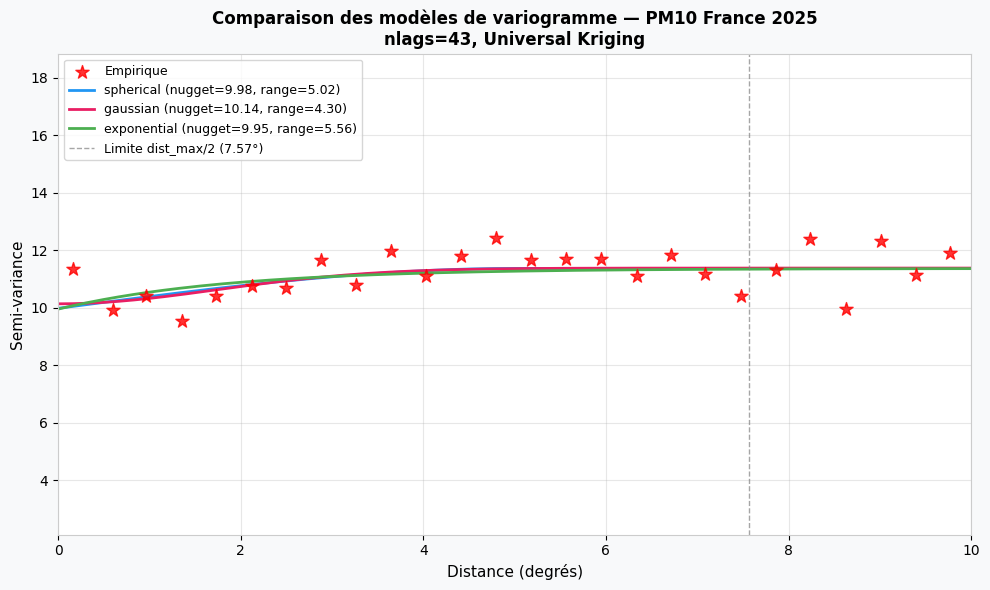

In [ ]:
from pykrige.uk import UniversalKriging
import matplotlib.pyplot as plt
import numpy as np

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

modeles = ["spherical", "gaussian", "exponential"]
colors = {"spherical": "#2196F3", "gaussian": "#E91E63", "exponential": "#4CAF50"}

# Fit des trois modèles
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('white')

for idx, modele in enumerate(modeles):
    UK = UniversalKriging(
        lons, lats, vals,
        variogram_model=modele,
        drift_terms=["regional_linear"],
        nlags=43,
        anisotropy_scaling=1.5,
        anisotropy_angle=0,
        verbose=False,
        enable_plotting=False
    )
    
    lags = UK.lags
    semivariance = UK.semivariance
    model_points = UK.variogram_function(UK.variogram_model_parameters, lags)
    
    # Points empiriques seulement sur le premier modèle
    if idx == 0:
        ax.scatter(lags, semivariance, c="red", marker="*", s=100, 
                   zorder=5, label="Empirique", alpha=0.8)
    
    # Ligne du modèle fitté
    x_line = np.linspace(0, lags.max(), 200)
    y_line = UK.variogram_function(UK.variogram_model_parameters, x_line)
    ax.plot(x_line, y_line, color=colors[modele], linewidth=2,
            label=f"{modele} (nugget={UK.variogram_model_parameters[2]:.2f}, range={UK.variogram_model_parameters[1]:.2f})")

# Zone utile
ax.axvline(x=7.57, color='grey', linewidth=1, linestyle='--', alpha=0.7, 
           label="Limite dist_max/2 (7.57°)")

ax.set_xlabel("Distance (degrés)", fontsize=11)
ax.set_ylabel("Semi-variance", fontsize=11)
ax.set_title("Comparaison des modèles de variogramme — PM10 France 2025\nnlags=43, Universal Kriging",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 10)  # zoom sur la zone utile

for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

plt.tight_layout()
plt.show()

# Inférence

In [39]:
# Points à prédire : liste de (nom, longitude, latitude)
points_inference = [
    ("Lyon",        4.8357,  45.7640),
    ("Bordeaux",   -0.5792,  44.8378),
    ("Toulouse",    1.4442,  43.6047),
    ("Nantes",     -1.5534,  47.2184),
    ("Montpellier", 3.8767,  43.6119),
    ("Strasbourg",  7.7521,  48.5734),
]

# Meilleur modèle : sphérique nlags=5
UK_final = UniversalKriging(
    lons_cv, lats_cv, vals_cv,
                variogram_model="spherical",
                drift_terms=["regional_linear"],
                nlags=43,
                anisotropy_scaling=1.5,
                anisotropy_angle=0,
                verbose=False,
                enable_plotting=False
)

# Prédiction
noms_pts = [p[0] for p in points_inference]
lons_pts = np.array([p[1] for p in points_inference])
lats_pts = np.array([p[2] for p in points_inference])

z_pred, variance_pred = UK_final.execute("points", lons_pts, lats_pts)

# Résultats
df_inference = pd.DataFrame({
    "Ville"           : noms_pts,
    "Longitude"       : lons_pts,
    "Latitude"        : lats_pts,
    "PM10 prédit"     : z_pred.round(2),
    "Écart-type pred" : np.sqrt(variance_pred).round(2),
    "IC bas (95%)"    : (z_pred - 1.96 * np.sqrt(variance_pred)).round(2),
    "IC haut (95%)"   : (z_pred + 1.96 * np.sqrt(variance_pred)).round(2),
})

print(df_inference.to_string(index=False))

      Ville  Longitude  Latitude  PM10 prédit  Écart-type pred  IC bas (95%)  IC haut (95%)
       Lyon     4.8357   45.7640        14.84             3.23          8.51          21.17
   Bordeaux    -0.5792   44.8378        15.09             3.27          8.68          21.50
   Toulouse     1.4442   43.6047        14.94             3.25          8.57          21.30
     Nantes    -1.5534   47.2184        14.35             3.25          7.98          20.71
Montpellier     3.8767   43.6119        16.13             3.27          9.72          22.54
 Strasbourg     7.7521   48.5734        15.94             3.28          9.50          22.38
